In [15]:
import numpy as np
import pandas as pd
import math
import astropy.constants as const
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sympy import denom

#inputs we set
h_agn = 0.017 * const.pc.cgs.value #height of the AGN in cm
dense_agn = 1e-16 #density of the AGN in cgs units
dense_sf = dense_agn * (((5/3)+1)/((5/3)-1)) #density of shock fluid (eq 34 from emilys notes)
c = const.c.cgs.value #speed of light in cm/s
dist = 500 * 1e6 * const.pc.cgs.value #distance to the AGN in cm (500 parsecs)
jet_angle = 0.05 # about 3 degrees in radians (set by paper)
v_fs = 0.6 * c #velocity of forward shock in cm/s breaks if < 0.7 c
#freq = 1e17 #frequency to test in Hz
freq_list = np.logspace(10, 25, 50000) #frequency range to test in Hz log space does 10^ before for the exponents
sound_speed = 5e6 #sound speed 50 km/s in cm/s
p = 2.5 #top right page 8, the power law index of the electron distribution
pa = np.sin(np.pi/2) #pitch angle set to 90 degrees
e = const.e.esu.value #elementary charge in esu (csg)
m_p = const.m_p.cgs.value #proton mass in cgs

#beta fs 
b_fs = v_fs / c #page 2 bottom right

#L_sh variable
l_sh = 5e43 * (jet_angle/0.05)**2 * (h_agn/5e16)**2 * (dense_agn/1e-16) * (b_fs/0.1)**3 #eq 5

#L_syn variable
e_e = 0.3 #page 8 top right
e_b = 0.1 #page 8 top right
f_dilution = 1 #page 6 left of eq 16
Yssc = (e_e / e_b)**(1/3) #page 8 top left
Y2ndIC = (e_e / e_b)**(2/3) #page 8 top left

#gamma related variables
xi = 1 #page 7 top left


#gamma equations
gamma_fs = 1/(np.sqrt(1 - b_fs**2)) #confirmed with emily

if b_fs < 0.7:
    gamma_sf = (7/6) * gamma_fs #from hiromichi
else:
    gamma_sf = gamma_fs / (np.sqrt(2)) #page 5 top left

#beta_sf eq (solve from Lorentz gamma)
v_sf = c * np.sqrt(1 - (1 / gamma_sf**2))

beta_sf = v_sf/c

a_gamma_sf = (gamma_sf-1) * (4*gamma_sf+3) #left of eq 24
gamma_sf_f = gamma_sf**(1 + np.sqrt(3)) #page 5 top left
gamma_m = 40 * (e_e/0.3) * ((gamma_sf-1)/0.2) #eq 16
gamma_max = 1e6 * (xi**(-0.5)) * (beta_sf/0.5) * ((a_gamma_sf/1.5)**(-0.25)) * ((e_b/0.1)**(-0.25)) * ((dense_agn/1e-16)**(-0.25)) #eq 17

# B_sf eq (page 7 top left)
B_sf = 600 * ((a_gamma_sf/1.5)**(0.5)) * ((e_b/0.1)**(0.5)) * ((dense_agn/1e-16)**(0.5))

def solve_gamma_a(case):
    gamma_a = gamma_m  # set equal to gamma_m for start guess

    #having the final values set to be an option to print
    final_tq = None
    final_cq = None
    final_tc = None

    for _ in range(100):  #looping it to find gamma a
        if case == 1:
            gamma_1 = gamma_a #when gamma m is larger than gamma a
            gamma_2 = gamma_m
            q = 2
        else:
            gamma_1 = gamma_m #when gamma a is larger than gamma m
            gamma_2 = gamma_max
            q = p #2.5

        #eq 20 (cooling timescale)
        tc_ga = 30 * ((e_b/0.1)**-1) * ((((gamma_sf-1)*(4*gamma_sf+3))/1.5)**-1) * ((dense_agn/1e-16)**-1) * ((gamma_sf/1.2)**-1) * ((gamma_a/60)**-1)

        delta_shell = tc_ga * v_fs

        #eq 20 (synchotron self absorption)
        ratio = gamma_2 / gamma_1

        if ratio <= 0: #case where gamma 2 is negatice or or it wont be possible
            return np.nan

        denom = 1 - (ratio ** (-q+1))
        
        
         # if gamma2/gamma1 to the power of (-q+1) is 1 the denom is negative and breaks
        if abs(denom) < 1e-10:
            denom = 1e-10

        # eq 22 (synchotron self absorption)
        tq = (np.pi/(3*np.sqrt(3))) * (((q**2 + q - 2)*(gamma_1**-5)) /denom) * ((e * dense_sf * delta_shell)/(B_sf * pa * m_p))

        #eq 23 (modified to be Cq+1)
        cq_1 = ((2**(((q+2)/2)))/(q+2)) * math.gamma(((q+1)/4)-(1/12)) * math.gamma(((q+1)/4)+(19/12))
        
        #storing the values used to get final gamma_a
        if np.isfinite(tq) and np.isfinite(cq_1) and np.isfinite(tc_ga): #this only picks real numbers when the eq doesnt break
            final_tq = tq
            final_cq = cq_1
            final_tc = tc_ga

        #eq 21 
        gamma_new = gamma_m * ((tq * cq_1)**(1/(q+4)))

        if abs(gamma_new - gamma_a)/gamma_a < 1e-3:
            return gamma_new, final_tq, final_cq, final_tc

        gamma_a = gamma_new
    return gamma_a, final_tq, final_cq, final_tc

gamma_a_small, tq_small, cq_small, tc_small = solve_gamma_a(case=1)
gamma_a_big, tq_big, cq_big, tc_big = solve_gamma_a(case=2)


if gamma_a_small < gamma_m:
    gamma_a = gamma_a_small
    tq_final = tq_small
    cq_final = cq_small
    tc_final = tc_small
    case = 1


else:
    gamma_a = gamma_a_big
    tq_final = tq_big
    cq_final = cq_big
    tc_final = tc_big
    case = 2

#page 6 under eq 15
if b_fs * gamma_fs <= 1: 
    f_beaming = 1
elif b_fs * gamma_fs > 1:
    f_beaming = 2 * (gamma_sf_f**2)

l_syn = e_e * f_beaming * f_dilution * (l_sh/(1 + Yssc + Y2ndIC)) # (eq 15)

#freq equations
freq_sync = 2e9 * (gamma_sf/1.2) * (B_sf/600) #eq 24
freq_m = 3e12 * (gamma_m/40)**2 * (freq_sync/2e9) #eq 25
freq_max = 2e21 * ((gamma_max/1e6)**2) * (freq_sync/2e9) #eq 26
freq_a = 7e12 * ((gamma_a/60)**2) * (freq_sync/2e9) #eq 27

freq_lum_list = []

for freq in freq_list:
    chosen_freq = 0 #initializing the variable
    if freq_a < freq_m:
        if freq_m < freq < freq_max:
            chosen_freq = (freq/freq_m)**((-p+2)/2)
        elif freq_a < freq < freq_m:
            chosen_freq = (freq/freq_m)**(1/2)
        elif freq_sync < freq < freq_a:
            chosen_freq = ((freq/freq_a)**3)*((freq_a/freq_m)**(1/2))
        else:
            chosen_freq = 0.1
    elif freq_m < freq_a: 
        if freq_a < freq < freq_max:
            chosen_freq = (freq/freq_m)** ((-p+2)/2) + np.exp(1-((freq/freq_a)**(1/2)))
        elif freq < freq_a: 
            chosen_freq = (freq/freq_a)**3
        else:
            chosen_freq = 0.2

    freq_lum_list.append((l_syn * chosen_freq)/(4 * np.pi * dist**2)) #making list of lum at each freq


freq_lum_list = np.array(freq_lum_list)


print(f"gamma_fs: {gamma_fs}")
print(f"gamma_a_small: {gamma_a_small}")
print(f"gamma_sf: {gamma_sf}")
print(f"gamma_m: {gamma_m}")
print(f"gamma_a: {gamma_a}" )
print(tq_small, cq_small, tc_small)
print(tq_big, cq_big, tc_big)
print(f"Final tq: {tq_final}")
print(f"Final cq_1: {cq_final}")
print(f"Final tc: {tc_final}")
print(f"Case: {case}")

print("freq sync: ", freq_sync)
print("freq a: ", freq_a)
print("freq m: ", freq_m)
print("freq max: ", freq_max)
print("lum list: ", freq_lum_list)
print("freq list: ", freq_list)

gamma_fs: 1.25
gamma_a_small: nan
gamma_sf: 1.4583333333333335
gamma_m: 91.6666666666667
gamma_a: 51.199356420729416
-3.170543998963345e-12 1.6122661015415265 0.29113197232074445
0.014160403924345456 1.602393838648818 10.714061989287657
Final tq: 0.014160403924345456
Final cq_1: 1.602393838648818
Final tc: 10.714061989287657
Case: 2
freq sync:  3993125446.6955533
freq a:  10176712404075.64
freq m:  31456261656911.605
freq max:  5.150793650793653e+21
lum list:  [1.42271558e-20 1.42566703e-20 1.42862460e-20 ... 2.63627308e-12
 2.63627308e-12 2.63627308e-12]
freq list:  [1.00000000e+10 1.00069103e+10 1.00138253e+10 ... 9.98619375e+24
 9.99309449e+24 1.00000000e+25]


/var/folders/pw/nc5rj5md667b29kntncq7jbw0000gn/T/ipykernel_1114/6390074.py:112: RuntimeWarning: invalid value encountered in scalar power
  gamma_new = gamma_m * ((tq * cq_1)**(1/(q+4)))


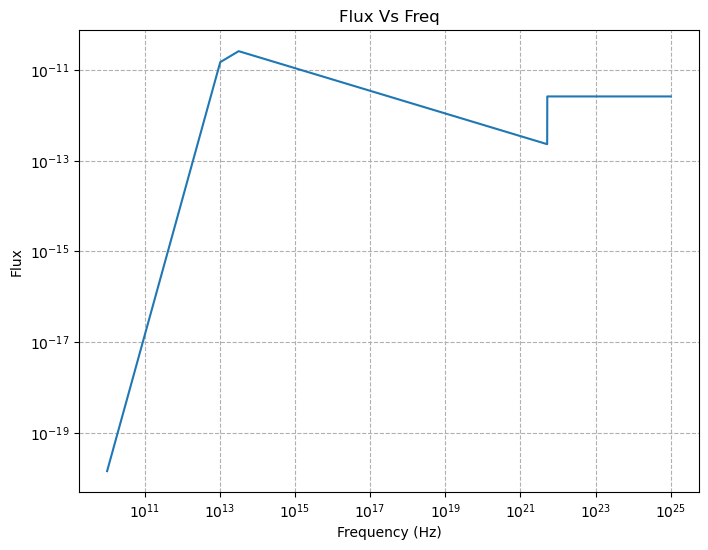

In [16]:
plt.figure(figsize=(8,6))
plt.loglog(freq_list, freq_lum_list)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Flux")
plt.title("Flux Vs Freq")

plt.grid(True, which="both", linestyle="--")
plt.show()

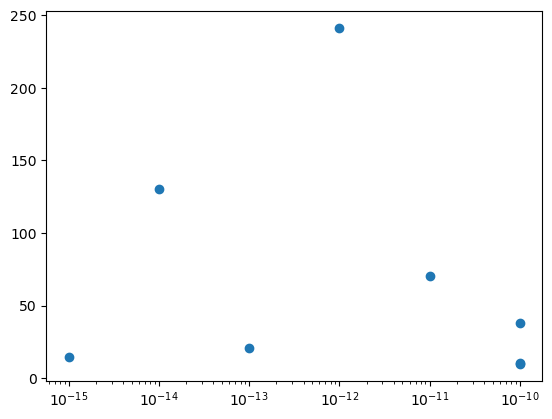

In [ ]:

dens_13 = 1e-13 #extra density for testing
dens_11 = 1e-11 #extra density for testing
dens_14 = 1e-14 #extra density for testing
dens_10 = 1e-10 #extra density for testing
dens_list = [dens_high,dens_high, dens_mid, dens_low, dens_13, dens_11, dens_14, dens_10]

#B_sf VARIABLE

B_sf_low = 6e2*((a_gamma_sf/1.5)**0.5) * ((e_b/0.1)**0.5) * (dens_low/1e-16)
B_sf_mid = 6e2*((a_gamma_sf/1.5)**0.5) * ((e_b/0.1)**0.5) * (dens_mid/1e-16)
B_sf_high = 6e2*((a_gamma_sf/1.5)**0.5) * ((e_b/0.1)**0.5) * (dens_high/1e-16)
B_sf_13 = 6e2*((a_gamma_sf/1.5)**0.5) * ((e_b/0.1)**0.5) * (dens_13/1e-16)
B_sf_11 = 6e2*((a_gamma_sf/1.5)**0.5) * ((e_b/0.1)**0.5) * (dens_11/1e-16)
B_sf_14 = 6e2*((a_gamma_sf/1.5)**0.5) * ((e_b/0.1)**0.5) * (dens_14/1e-16)
B_sf_10 = 6e2*((a_gamma_sf/1.5)**0.5) * ((e_b/0.1)**0.5) * (dens_10/1e-16)

#TESTING CONSTANTS
#dense list changed above
gamma_max_13 = 1e6 * xi**(-0.5) * (b_sf/0.5)*((a_gamma_sf/1.5)**(-0.25))*((e_b/0.1)**(-0.25))*((dens_13/1e-16)**(-0.25)) #used in eq 26 from eq 17
gamma_max_11 = 1e6 * xi**(-0.5) * (b_sf/0.5)*((a_gamma_sf/1.5)**(-0.25))*((e_b/0.1)**(-0.25))*((dens_11/1e-16)**(-0.25)) #used in eq 26 from eq 17
gamma_max_14 = 1e6 * xi**(-0.5) * (b_sf/0.5)*((a_gamma_sf/1.5)**(-0.25))*((e_b/0.1)**(-0.25))*((dens_14/1e-16)**(-0.25)) #used in eq 26 from eq 17
gamma_max_10 = 1e6 * xi**(-0.5) * (b_sf/0.5)*((a_gamma_sf/1.5)**(-0.25))*((e_b/0.1)**(-0.25))*((dens_10/1e-16)**(-0.25)) #used in eq 26 from eq 17



def gamma_a_big(): #when gamma_a > gamma_m
    q = 2.5 #need to set it to 2 when gamma_a > gamma_m
    gamma_2_low = gamma_max_low #set to gamma_m when gamma_a > gamma_m
    gamma_2_mid = gamma_max_mid 
    gamma_2_high = gamma_max_high 
    gamma_1 = gamma_m #set to gamma_max when gamma_a > gamma_m
    e = const.e.value
    pa = np.sin(np.pi/2) #set to 90 degrees for the pitch angle
    rho_sf = 1 #placeholder for now need to hear from Hiromichi
    #TESTING
    gamma_2_11 = gamma_max_11
    gamma_2_13 = gamma_max_13
    gamma_2_14 = gamma_max_14
    gamma_2_10 = gamma_max_10
    #mid plane 1e-9 density
    tc_gm = 3*10 * ((e_b/0.1)**-1)* ((((gamma_sf-1)*(4*gamma_sf+3))/1.5)**-1) * ((dens_high/1e-16)**-1) * ((gamma_sf/1.2)**-1) * ((gamma_m/40)**-1) #eq 20, the last term needs to be changed to gamma_a for big one
    delta_shell_m = tc_gm * v_fs #need to make this to delta shell gamma_a for the next calculation
    tq_gm = (np.pi/3*np.sqrt(3)) * (((q**2 + q -2)*(gamma_1**-5))/1-((gamma_2_high/gamma_1)**(-q+1))) * ((e*rho_sf*delta_shell_m)/(B_sf_high*pa*const.m_p.cgs.value)) #eq 22 need to change delta shell to delta shell gamma a
    cq_1 = ((2**(((q+1)+1)/2))/((q+1)+1)) * math.gamma(((q+1)/4)-(1/12)) * math.gamma(((q+1)/4)+(19/12)) #eq 23 for Cq+1
    gamma_a_m = gamma_m * ((tq_gm * cq_1)**(1/(q+4))) #eq 21 to start not sure how to make it
    #mid plane gamma_a 1e-9 density
    tc_ga0 = 3*10 * ((e_b/0.1)**-1)* ((((gamma_sf-1)*(4*gamma_sf+3))/1.5)**-1) * ((dens_high/1e-16)**-1) * ((gamma_sf/1.2)**-1) * ((gamma_a_m/60)**-1) #eq 20 edited to use gamma_a instead of gamma_m
    delta_shell_a = tc_ga0 * v_fs #reuse this for gamma_a need to make it into a loop
    tq_ga0 = (np.pi/3*np.sqrt(3)) * ((q**2 + q -2)*(gamma_1**-5)/1-((gamma_2_high/gamma_1)**(-q+1))) * ((e*rho_sf*delta_shell_a)/(B_sf_high*pa*const.m_p.cgs.value)) #eq 22 need to make into loop
    gamma_a0 = gamma_m * ((tq_ga0 * cq_1)**(1/(q+4)))

    #Test 1e-10
    tc_ga10 = 3*10 * ((e_b/0.1)**-1)* ((((gamma_sf-1)*(4*gamma_sf+3))/1.5)**-1) * ((dens_10/1e-16)**-1) * ((gamma_sf/1.2)**-1) * ((gamma_a0/60)**-1) #eq 20 edited to use gamma_a instead of gamma_m
    delta_shell_a10 = tc_ga10 * v_fs #reuse this for gamma_a need to make it into a loop
    tq_ga10 = (np.pi/3*np.sqrt(3)) * ((q**2 + q -2)*(gamma_1**-5)/1-((gamma_2_10/gamma_1)**(-q+1))) * ((e*rho_sf*delta_shell_a10)/(B_sf_10*pa*const.m_p.cgs.value)) #eq 22 need to make into loop
    gamma_a10 = gamma_m * ((tq_ga10 * cq_1)**(1/(q+4)))


    #TEST FOR 1e-11 
    tc_ga11 = 3*10 * ((e_b/0.1)**-1)* ((((gamma_sf-1)*(4*gamma_sf+3))/1.5)**-1) * ((dens_11/1e-16)**-1) * ((gamma_sf/1.2)**-1) * ((gamma_a10/60)**-1) #eq 20 edited to use gamma_a instead of gamma_m
    delta_shell_a11 = tc_ga11 * v_fs #reuse this for gamma_a need to make it into a loop
    tq_ga11 = (np.pi/3*np.sqrt(3)) * ((q**2 + q -2)*(gamma_1**-5)/1-((gamma_2_11/gamma_1)**(-q+1))) * ((e*rho_sf*delta_shell_a11)/(B_sf_11*pa*const.m_p.cgs.value)) #eq 22 need to make into loop
    gamma_a11 = gamma_m * ((tq_ga11 * cq_1)**(1/(q+4)))


    #higher up 1e-12 density
    tc_ga = 3*10 * ((e_b/0.1)**-1)* ((((gamma_sf-1)*(4*gamma_sf+3))/1.5)**-1) * ((dens_mid/1e-16)**-1) * ((gamma_sf/1.2)**-1) * ((gamma_a11/60)**-1) #eq 20 edited to use gamma_a instead of gamma_m
    delta_shell_a = tc_ga * v_fs #reuse this for gamma_a need to make it into a loop
    tq_ga = (np.pi/3*np.sqrt(3)) * ((q**2 + q -2)*(gamma_1**-5)/1-((gamma_2_mid/gamma_1)**(-q+1))) * ((e*rho_sf*delta_shell_a)/(B_sf_mid*pa*const.m_p.cgs.value)) #eq 22 need to make into loop
    gamma_a1 = gamma_m * ((tq_ga * cq_1)**(1/(q+4)))

    # 1e-13 test
    tc_ga13 = 3*10 * ((e_b/0.1)**-1)* ((((gamma_sf-1)*(4*gamma_sf+3))/1.5)**-1) * ((dens_13/1e-16)**-1) * ((gamma_sf/1.2)**-1) * ((gamma_a1/60)**-1) #eq 20 edited to use gamma_a instead of gamma_m
    delta_shell_a13 = tc_ga13 * v_fs #reuse this for gamma_a need to make it into a loop
    tq_ga13 = (np.pi/3*np.sqrt(3)) * ((q**2 + q -2)*(gamma_1**-5)/1-((gamma_2_13/gamma_1)**(-q+1))) * ((e*rho_sf*delta_shell_a13)/(B_sf_13*pa*const.m_p.cgs.value)) #eq 22 need to make into loop
    gamma_a13 = gamma_m * ((tq_ga13 * cq_1)**(1/(q+4)))

    # 1e-14 test
    tc_ga14 = 3*10 * ((e_b/0.1)**-1)* ((((gamma_sf-1)*(4*gamma_sf+3))/1.5)**-1) * ((dens_14/1e-16)**-1) * ((gamma_sf/1.2)**-1) * ((gamma_a13/60)**-1) #eq 20 edited to use gamma_a instead of gamma_m
    delta_shell_a14 = tc_ga14 * v_fs #reuse this for gamma_a need to make it into a loop
    tq_ga14 = (np.pi/3*np.sqrt(3)) * ((q**2 + q -2)*(gamma_1**-5)/1-((gamma_2_14/gamma_1)**(-q+1))) * ((e*rho_sf*delta_shell_a14)/(B_sf_14*pa*const.m_p.cgs.value)) #eq 22 need to make into loop
    gamma_a14 = gamma_m * ((tq_ga14 * cq_1)**(1/(q+4)))


    #top of the disk 1e-15 density
    tc_ga1 = 3*10 * ((e_b/0.1)**-1)* ((((gamma_sf-1)*(4*gamma_sf+3))/1.5)**-1) * ((dens_low/1e-16)**-1) * ((gamma_sf/1.2)**-1) * ((gamma_a14/60)**-1) #eq 20 edited to use gamma_a instead of gamma_m
    delta_shell_a1 = tc_ga1 * v_fs #reuse this for gamma_a need to make it into a loop
    tq_ga1 = (np.pi/3*np.sqrt(3)) * ((q**2 + q -2)*(gamma_1**-5)/1-((gamma_2_low/gamma_1)**(-q+1))) * ((e*rho_sf*delta_shell_a1)/(B_sf_low*pa*const.m_p.cgs.value)) #eq 22 need to make into loop
    gamma_a2 = gamma_m * ((tq_ga1 * cq_1)**(1/(q+4)))




    return gamma_a0, gamma_a1, gamma_a2, gamma_a_m, gamma_a11, gamma_a13, gamma_a14, gamma_a10

plt.scatter(dens_list, gamma_a_big())
plt.xscale('log')

In [ ]:
import numpy as np
import pandas as pd
import math
import astropy.constants as const
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

#inputs we set
h_agn = 1e12 #height of the AGN in cm
dense_agn = 1e-10 #density of the AGN in cgs units
dense_sf = dense_agn * (((5/3)+1)/((5/3)-1)) #density of shock fluid (eq 34 from emilys notes)
c = const.c.cgs.value #speed of light in cm/s
jet_angle = 0.05 # about 3 degrees in radians (set by paper)
v_fs = 0.71 * c #velocity of forward shock in cm/s
freq = 1e17 #frequency range to test in Hz
sound_speed = 5e6 #sound speed 50 km/s in cm/s
p = 2.5 #top right page 8, the power law index of the electron distribution
pa = np.sin(np.pi/2) #pitch angle set to 90 degrees
e = const.e.esu.value #elementary charge in esu (csg)
m_p = const.m_p.cgs.value #proton mass in cgs

#beta fs 
b_fs = v_fs / c #page 2 bottom right

#L_sh variable
l_sh = 5e43 * (jet_angle/0.05)**2 * (h_agn/5e16)**2 * (dense_agn/1e-16) * (b_fs/0.1)**3 #eq 5

#L_syn variable
e_e = 0.3 #page 8 top right
e_b = 0.1 #page 8 top right
f_dilution = 1 #page 6 left of eq 16
Yssc = (e_e / e_b)**(1/3) #page 8 top left
Y2ndIC = (e_e / e_b)**(2/3) #page 8 top left

#gamma related variables
xi = 1 #page 7 top left

#beta_sf eq
p2 = 1 + 5/3 * 1 #eq 32 from emilys notes
p1 = 1 + ((5/3) * (v_fs/sound_speed)**2) #eq 32 from emilys notes
c1 = np.sqrt(((5/3)*p1)/dense_agn)
beta_sf = b_fs + c1 * (1+ ((5/3)+1)/(2 * (5/3)) * ((p2/p1)-1))**0.5

#gamma equations
gamma_fs = 1/(np.sqrt(1 - b_fs**2)) #confirmed with emily
gamma_sf = gamma_fs / (np.sqrt(2)) #page 5 top left
a_gamma_sf = (gamma_sf-1) * (4*gamma_sf+3) #left of eq 24
gamma_sf_f = gamma_sf**(1 + np.sqrt(3)) #page 5 top left
gamma_m = 40 * (e_e/0.3) * ((gamma_sf-1)/0.2) #eq 16
gamma_max = 1e6 * (xi**(-0.5)) * (beta_sf/0.5) * ((a_gamma_sf/1.5)**(-0.25)) * ((e_b/0.1)**(-0.25)) * ((dense_agn/1e-16)**(-0.25)) #eq 17

# B_sf eq (page 7 top left)
B_sf = 600 * ((a_gamma_sf/1.5)**(0.5)) * ((e_b/0.1)**(0.5)) * ((dense_agn/1e-16)**(0.5))

#gamma_a eq
if gamma_m < 60: #set for now to 60, need to make it loop so it compares to gamma_a. found under eq 23
    gamma_2 = gamma_max
    gamma_1 = gamma_m
    q = p
elif gamma_m > 60: # need to change this to gamma_a 
    gamma_2 = gamma_m
    gamma_1 = 60 #need to change this to gamma_a
    q = 2 

tc_gm = 30 * ((e_b/0.1)**-1)* ((((gamma_sf-1)*(4*gamma_sf+3))/1.5)**-1) * ((dense_agn/1e-16)**-1) * ((gamma_sf/1.2)**-1) * ((gamma_m/40)**-1) #eq 20, the last term needs to be changed to gamma_a for big one
delta_shell_m = tc_gm * v_fs #need to make this to delta shell gamma_a for the next calculation
tq_gm = (np.pi/(3*np.sqrt(3))) * (((q**2+ q -2) * (gamma_1**-5))/ (1- ((gamma_2/gamma_1)**(-q+1)))) * ((e * dense_sf * delta_shell_m)/(B_sf * pa * m_p)) #eq 22 need to change delta shell to delta shell gamma a
cq_1 = ((2**(((q+1)+1)/2))/((q+1)+1)) * math.gamma(((q+1)/4)-(1/12)) * math.gamma(((q+1)/4)+(19/12)) #eq 23 for Cq+1
gamma_a_m = gamma_m * ((tq_gm * cq_1)**(1/(q+4))) #eq 21 to start not sure how to make it
#loop for gamma_a
tc_ga0 = 30 * ((e_b/0.1)**-1)* ((((gamma_sf-1)*(4*gamma_sf+3))/1.5)**-1) * ((dense_agn/1e-16)**-1) * ((gamma_sf/1.2)**-1) * ((gamma_a_m/60)**-1) #eq 20 edited to use gamma_a instead of gamma_m
delta_shell_a = tc_ga0 * v_fs #reuse this for gamma_a need to make it into a loop
tq_ga0 = (np.pi/(3*np.sqrt(3))) * (((q**2 + q -2)*(gamma_1**-5))/ (1-((gamma_2/gamma_1)**(-q+1)))) * ((e*dense_sf*delta_shell_a)/(B_sf*pa*m_p)) #eq 22 need to make into loop
gamma_a0 = gamma_m * ((tq_ga0 * cq_1)**(1/(q+4)))

#page 6 under eq 15
if b_fs * gamma_fs <= 1: 
    f_beaming = 1
elif b_fs * gamma_fs > 1:
    f_beaming = 2 * (gamma_sf_f**2)

l_syn = e_e * f_beaming * f_dilution * (l_sh/(1 + Yssc + Y2ndIC)) # (eq 15)

#freq equations
freq_sync = 2e9 * (gamma_sf/1.2) * (B_sf/600) #eq 24
freq_m = 3e12 * (gamma_m/40)**2 * (freq_sync/2e9) #eq 25
freq_max = 2e21 * ((gamma_max/1e6)**2) * (freq_sync/2e9) #eq 26
freq_a = 7e12 * ((gamma_a0/60)**2) * (freq_sync/2e9) #eq 27

if freq_a < freq_m:
    if freq_m < freq < freq_max:
        chosen_freq = (freq/freq_m)**((-p+2)/2)
    elif freq_a < freq < freq_m:
        chosen_freq = (freq/freq_m)**(1/2)
    elif freq_sync < freq < freq_a:
        chosen_freq = ((freq/freq_a)**3)*((freq_a/freq_m)**(1/2))
    else:
        chosen_freq = 0.1
elif freq_m < freq_a: 
    if freq_a < freq < freq_max:
        chosen_freq = (freq/freq_m)** ((-p+2)/2) + np.exp(1-((freq/freq_a)**(1/2)))
    elif freq < freq_a: 
        chosen_freq = (freq/freq_a)**3
    else:
        chosen_freq = 0.2


freq_lum = l_syn * chosen_freq



IndentationError: unindent does not match any outer indentation level (<string>, line 59)